In [1]:
# !pip install -U boto3 botocore

import os
import json
import base64
from pathlib import Path
import boto3
from botocore.exceptions import ClientError

In [2]:
pip install pillow

Note: you may need to restart the kernel to use updated packages.


In [3]:
from PIL import Image
import io

def shrink_image_bytes(
    img_bytes: bytes,
    max_size_mb: int = 5,
    max_dim: int = 2048,
) -> bytes:
    """
    Resize + JPEG compress image so it's under Bedrock 5MB limit.
    """
    img = Image.open(io.BytesIO(img_bytes)).convert("RGB")

    # Resize (keep aspect ratio)
    img.thumbnail((max_dim, max_dim))

    quality = 90
    while True:
        buf = io.BytesIO()
        img.save(buf, format="JPEG", quality=quality, optimize=True)
        size_mb = buf.tell() / (1024 * 1024)

        if size_mb <= max_size_mb or quality <= 40:
            return buf.getvalue()

        quality -= 10

In [ ]:
AWS_REGION = os.getenv("AWS_REGION", "us-east-2")
MODEL_ID = os.getenv("BEDROCK_MODEL_ID", "anthropic.claude-opus-4-5-20251101-v1:0")


In [11]:
import boto3
import json
from pathlib import Path
from urllib.parse import urlparse
from PIL import Image
import io

bedrock = boto3.client("bedrock-runtime", region_name="us-east-2")
s3 = boto3.client("s3")

INFERENCE_PROFILE_ARN = "arn:aws:bedrock:us-east-2:727117753557:inference-profile/us.anthropic.claude-opus-4-5-20251101-v1:0"

def load_image_bytes(image_path: str) -> bytes:
    if image_path.startswith("s3://"):
        parsed = urlparse(image_path)
        bucket = parsed.netloc
        key = parsed.path.lstrip("/")
        obj = s3.get_object(Bucket=bucket, Key=key)
        return obj["Body"].read()
    return Path(image_path).read_bytes()

def shrink_to_jpeg_under_5mb(img_bytes: bytes, max_dim: int = 2048) -> bytes:
    img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
    img.thumbnail((max_dim, max_dim))

    quality = 90
    while True:
        buf = io.BytesIO()
        img.save(
            buf,
            format="JPEG",
            quality=quality,
            optimize=True,
            progressive=False,  # important: baseline JPEG
        )
        out = buf.getvalue()
        if len(out) <= 5 * 1024 * 1024 or quality <= 40:
            return out
        quality -= 10

def classify_beaver(image_path: str):
    raw = load_image_bytes(image_path)
    jpeg_bytes = shrink_to_jpeg_under_5mb(raw)

    prompt = (
        "You are a wildlife expert. Decide whether the image contains a beaver.\n"
        "IMPORTANT: - Many beavers are partially occluded, far away, or only show tails, silhouettes, or water disturbance.\n"
        "If there is ANY reasonable visual evidence of a beaver, classify as beaver.\n"
        "Return STRICT JSON only:\n"
        '{"is_beaver": true/false, "confidence": 0-1, "reason": "short"}'
    )

    resp = bedrock.converse(
        modelId=INFERENCE_PROFILE_ARN,
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "image": {
                            "format": "jpeg",
                            "source": {"bytes": jpeg_bytes},  # raw bytes (no base64)
                        }
                    },
                    {"text": prompt},
                ],
            }
        ],
        inferenceConfig={"temperature": 0.0, "maxTokens": 200},
    )

    text = resp["output"]["message"]["content"][0]["text"].strip()
    return json.loads(text)

In [7]:
result = classify_beaver(
    "s3://dfw-beaver-aug-ohio/original/train/beaver/beavertail_20240501_211829_05010513.jpg"
)
print(result)

{'is_beaver': True, 'confidence': 0.85, 'reason': 'Dark, stocky rodent with characteristic beaver body shape visible on fallen logs near water, with what appears to be a flat, paddle-shaped tail visible. Setting shows typical beaver habitat with gnawed logs and waterside location.'}


In [8]:
###batch test

In [12]:
import boto3
from concurrent.futures import ThreadPoolExecutor, as_completed
from urllib.parse import urlparse

s3 = boto3.client("s3")

def list_s3_images(bucket: str, prefix: str):
    paginator = s3.get_paginator("list_objects_v2")
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            key = obj["Key"]
            lower = key.lower()
            if lower.endswith((".jpg", ".jpeg", ".png", ".webp")):
                yield f"s3://{bucket}/{key}"

def evaluate_all_beaver(
    s3_prefix: str,
    max_workers: int = 6,
    limit: int | None = None,  # set e.g. 200 for a cheaper test
    count_errors_as_wrong: bool = True,
):
    parsed = urlparse(s3_prefix)
    bucket = parsed.netloc
    prefix = parsed.path.lstrip("/")

    paths = []
    for p in list_s3_images(bucket, prefix):
        paths.append(p)
        if limit is not None and len(paths) >= limit:
            break

    total = len(paths)
    if total == 0:
        return {"total": 0, "tp": 0, "fn": 0, "errors": 0, "accuracy": None}

    tp = 0  # predicted beaver True
    fn = 0  # predicted beaver False
    errors = 0

    def _run(path):
        r = classify_beaver(path)  # uses your working function
        return path, r

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = [ex.submit(_run, p) for p in paths]
        done = 0
        for fut in as_completed(futures):
            done += 1
            try:
                path, r = fut.result()
                if bool(r.get("is_beaver")):
                    tp += 1
                else:
                    fn += 1
            except Exception:
                errors += 1

            if done % 25 == 0 or done == total:
                print(f"Progress: {done}/{total} | tp={tp} fn={fn} errors={errors}")

    denom = total if count_errors_as_wrong else (tp + fn)
    accuracy = (tp / denom) if denom > 0 else None

    return {
        "total": total,
        "tp": tp,
        "fn": fn,
        "errors": errors,
        "accuracy": accuracy,  # since all are beaver, this is "beaver detection rate"
        "denominator": denom,
    }

In [13]:
result = evaluate_all_beaver(
    "s3://dfw-beaver-aug-ohio/original/train/beaver/",
    max_workers=6,
    limit=None,
    count_errors_as_wrong=True
)

result

Progress: 25/592 | tp=24 fn=1 errors=0
Progress: 50/592 | tp=48 fn=2 errors=0
Progress: 75/592 | tp=70 fn=5 errors=0
Progress: 100/592 | tp=91 fn=9 errors=0
Progress: 125/592 | tp=115 fn=10 errors=0
Progress: 150/592 | tp=139 fn=11 errors=0
Progress: 175/592 | tp=162 fn=13 errors=0
Progress: 200/592 | tp=187 fn=13 errors=0
Progress: 225/592 | tp=211 fn=14 errors=0
Progress: 250/592 | tp=231 fn=19 errors=0
Progress: 275/592 | tp=252 fn=23 errors=0
Progress: 300/592 | tp=275 fn=25 errors=0
Progress: 325/592 | tp=298 fn=27 errors=0
Progress: 350/592 | tp=320 fn=30 errors=0
Progress: 375/592 | tp=343 fn=32 errors=0
Progress: 400/592 | tp=368 fn=32 errors=0
Progress: 425/592 | tp=389 fn=36 errors=0
Progress: 450/592 | tp=411 fn=39 errors=0
Progress: 475/592 | tp=435 fn=40 errors=0
Progress: 500/592 | tp=458 fn=42 errors=0
Progress: 525/592 | tp=483 fn=42 errors=0
Progress: 550/592 | tp=508 fn=42 errors=0
Progress: 575/592 | tp=533 fn=42 errors=0
Progress: 592/592 | tp=550 fn=42 errors=0


{'total': 592,
 'tp': 550,
 'fn': 42,
 'errors': 0,
 'accuracy': 0.9290540540540541,
 'denominator': 592}

In [3]:
import boto3, json, io
from PIL import Image, ImageDraw
from urllib.parse import urlparse
from pathlib import Path

bedrock = boto3.client("bedrock-runtime", region_name="us-east-2")
s3 = boto3.client("s3")

INFERENCE_PROFILE_ARN = "arn:aws:bedrock:us-east-2:727117753557:inference-profile/us.anthropic.claude-opus-4-5-20251101-v1:0"

def load_image_bytes(image_path: str) -> bytes:
    if image_path.startswith("s3://"):
        p = urlparse(image_path)
        obj = s3.get_object(Bucket=p.netloc, Key=p.path.lstrip("/"))
        return obj["Body"].read()
    return Path(image_path).read_bytes()

def shrink_to_jpeg_under_5mb(img_bytes: bytes, max_dim: int = 2048) -> bytes:
    img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
    img.thumbnail((max_dim, max_dim))

    quality = 90
    while True:
        buf = io.BytesIO()
        img.save(buf, format="JPEG", quality=quality, optimize=True, progressive=False)
        out = buf.getvalue()
        if len(out) <= 5 * 1024 * 1024 or quality <= 40:
            return out
        quality -= 10

def beaver_bbox(image_path: str):
    raw = load_image_bytes(image_path)
    jpeg_bytes = shrink_to_jpeg_under_5mb(raw)

    prompt = """
You are a wildlife vision annotator.

Task:
1) Decide if there is a beaver in the image.
2) If yes, output ONE bounding box that tightly encloses the most visible beaver.

Return STRICT JSON only:
{
  "is_beaver": true/false,
  "confidence": 0-1,
  "bbox": [x1, y1, x2, y2]  // normalized 0-1 coordinates, top-left (x1,y1) to bottom-right (x2,y2)
}
Output MUST start with "{" and end with "}" and contain nothing else.

Rules:
- If no beaver, set bbox to null.
- Coordinates must be within [0,1].
"""

    resp = bedrock.converse(
        modelId=INFERENCE_PROFILE_ARN,
        messages=[{
            "role": "user",
            "content": [
                {"image": {"format": "jpeg", "source": {"bytes": jpeg_bytes}}},
                {"text": prompt}
            ],
        }],
        inferenceConfig={"temperature": 0.0, "maxTokens": 300},
    )

    text = resp["output"]["message"]["content"][0]["text"]
    data = extract_json_object(text)
    return data, jpeg_bytes

In [4]:
import json
import re

def extract_json_object(text: str) -> dict:
    """
    Extract the first JSON object from a text blob.
    Works even if the model adds extra words before/after.
    """
    if not text:
        raise ValueError("Empty model output")

    # Try direct parse first
    try:
        return json.loads(text)
    except Exception:
        pass

    # Try to find a {...} block
    m = re.search(r"\{[\s\S]*\}", text)
    if not m:
        raise ValueError(f"No JSON object found in model output: {text[:200]!r}")

    return json.loads(m.group(0))

{'is_beaver': True, 'confidence': 0.85, 'bbox': [0.52, 0.48, 0.68, 0.72]}


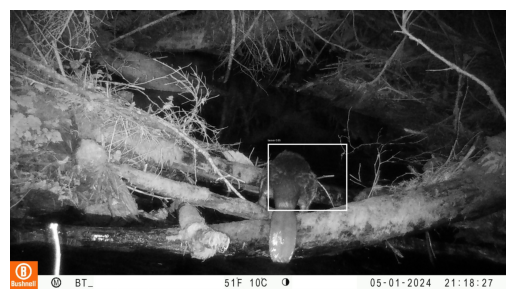

In [5]:
from PIL import Image
import matplotlib.pyplot as plt
import io

def draw_bbox_on_image(jpeg_bytes: bytes, bbox, label="beaver"):
    img = Image.open(io.BytesIO(jpeg_bytes)).convert("RGB")
    if bbox is None:
        return img

    w, h = img.size
    x1, y1, x2, y2 = bbox
    x1, y1, x2, y2 = int(x1*w), int(y1*h), int(x2*w), int(y2*h)

    draw = ImageDraw.Draw(img)
    draw.rectangle([x1, y1, x2, y2], width=5)
    draw.text((x1, max(0, y1-20)), label)
    return img

# Example
path = "s3://dfw-beaver-aug-ohio/original/train/beaver/beavertail_20240501_211829_05010513.jpg"
data, jpeg_bytes = beaver_bbox(path)

print(data)

img_boxed = draw_bbox_on_image(
    jpeg_bytes,
    data.get("bbox"),
    label=f"beaver {data.get('confidence', 0):.2f}"
)

plt.figure()
plt.imshow(img_boxed)
plt.axis("off")
plt.show()